***

### DL & GEN AI

### PRACTICAL 5: AUTOENCODER

***

## 1] import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)

## 2] load the dataset

In [2]:
digits = load_digits()
x = digits.data
y = digits.target
images = digits.images

print("Number of samples: ",x.shape[0])
print("Number of features: ",x.shape[1])
print("Image size: ",images.shape[1:])
print("Classes: ",np.unique(y))
print("Minimum pixel: ",x.min())
print("Maximum pixel: ",x.max())

Number of samples:  1797
Number of features:  64
Image size:  (8, 8)
Classes:  [0 1 2 3 4 5 6 7 8 9]
Minimum pixel:  0.0
Maximum pixel:  16.0


## 3] prepare the data

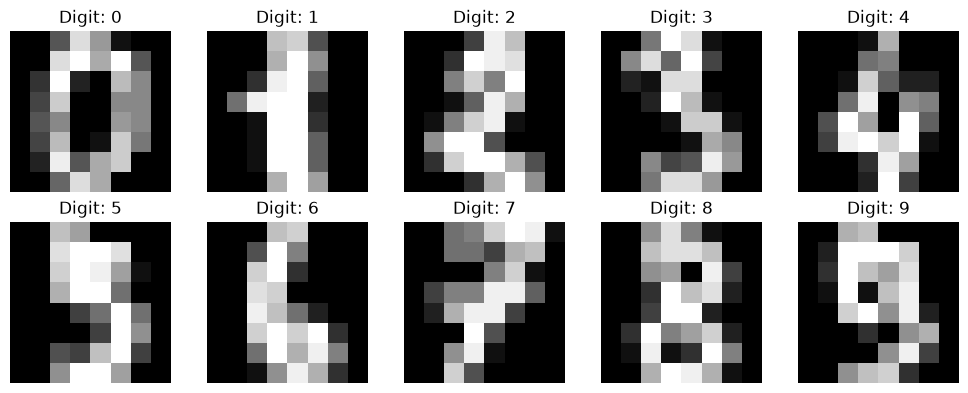

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4] build the autoencoder

In [6]:
x_normalized = x / 16.0
print("min: ",x_normalized.min())
print("max: ",x_normalized.max())
print("shape: ",x_normalized.shape)

min:  0.0
max:  1.0
shape:  (1797, 64)


## 5] compile the model

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x_normalized,y,test_size=0.20,random_state=42,stratify=y)
print("x train shape: ",x_train.shape)
print("x test shape",x_test.shape)

x train shape:  (1437, 64)
x test shape (360, 64)


## 6] train the autoencoder

In [10]:
LATENT_DIMENSION = 32

autoencoder = MLPRegressor(
    hidden_layer_sizes=(LATENT_DIMENSION,),
    activation="logistic",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

print("Input shape: ", x_train.shape[1])
print("LATENT_DIMENSION: ", LATENT_DIMENSION)
print("Output shape: ", x_train.shape[1])

Input shape:  64
LATENT_DIMENSION:  32
Output shape:  64


## 7] evaluate the model

In [11]:
autoencoder.fit(x_train,x_train)
print("iterations: ",autoencoder.n_iter_)
print("final loss: ",autoencoder.loss_)

iterations:  247
final loss:  0.0019889482452783267


## 8] visualize the results

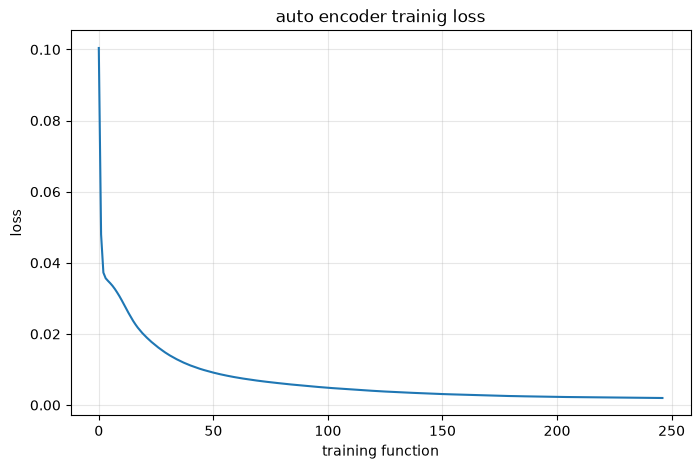

In [13]:
plt.figure(figsize=(8,5))
plt.plot(autoencoder.loss_curve_)
plt.xlabel("training function")
plt.ylabel("loss")
plt.title("auto encoder trainig loss")
plt.grid(True, alpha=0.3)
plt.show()

## 9] reconstruct the images

In [15]:
x_reconstructed = autoencoder.predict(x_test)
x_reconstructed = np.clip(x_reconstructed, 0.0, 1.0)
print("og shape: ",x_test.shape)
print("reconstructed shape: ",x_reconstructed.shape)

og shape:  (360, 64)
reconstructed shape:  (360, 64)


## 10] analyze the latent representation

In [17]:
mse = mean_squared_error(x_test, x_reconstructed)
print(f"test reconstruction MSE: {mse:.6f}")

test reconstruction MSE: 0.003443


## 11] implementation

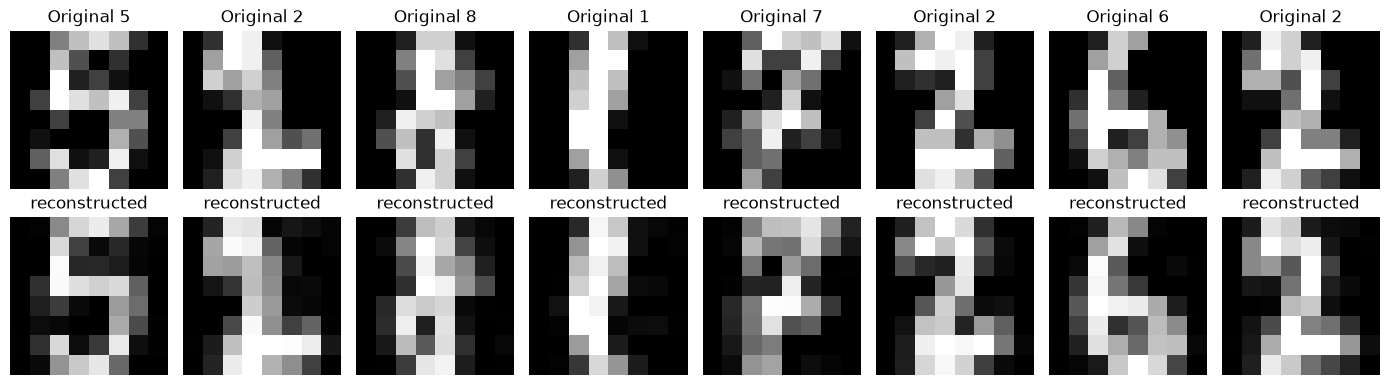

In [20]:
N = 8
fig, axes = plt.subplots(2, N, figsize=(14, 4))
for i in range(N):
    axes[0,i].imshow(x_test[i].reshape(8,8),cmap='gray',vmin=0,vmax=1)
    axes[0,i].set_title(f"Original {y_test[i]}")
    axes[0,i].axis("off")
    axes[1,i].imshow(x_reconstructed[i].reshape(8,8),cmap='gray',vmin=0,vmax=1)
    axes[1,i].set_title("reconstructed")
    axes[1,i].axis("off")
plt.tight_layout()
plt.show()

## 12] implementation

In [22]:
def sigmoid(values):
    values = np.clip(values, -50, 50)
    return 1.0 / (1.0 + np.exp(-values))

encoder_weights = autoencoder.coefs_[0]
encoder_bias = autoencoder.intercepts_[0]

z_test = sigmoid(x_test @ encoder_weights + encoder_bias)
print("og shape: ", x_test.shape)
print("latent feature shape: ", z_test.shape)

og shape:  (360, 64)
latent feature shape:  (360, 32)


## 13] implementation

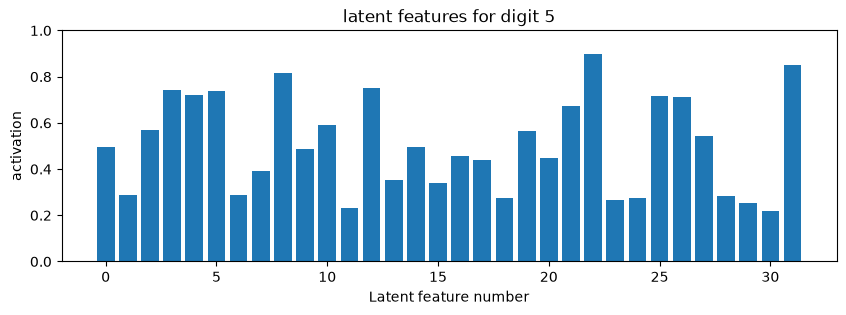

In [24]:
sample_index = 0
plt.figure(figsize=(10,3))
plt.bar(np.arange(LATENT_DIMENSION), z_test[sample_index])

plt.xlabel("Latent feature number")
plt.ylabel("activation")
plt.title(f"latent features for digit {y_test[sample_index]}")
plt.ylim(0,1)
plt.show()

## 14] implementation

Text(0.5, 1.0, 'AE output')

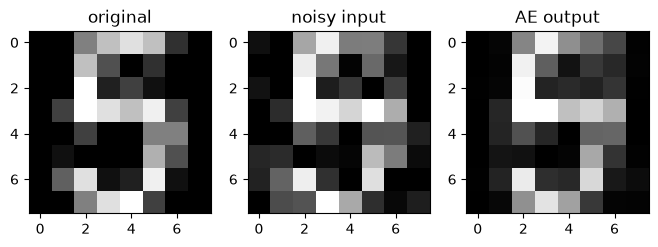

In [26]:
rng = np.random.default_rng(42)
sample = x_test[0]
noise = rng.normal(loc=0.0, scale=0.20, size=sample.shape)

noisy_sample = np.clip(sample + noise, 0.0, 1.0)
ae_output = autoencoder.predict(noisy_sample.reshape(1,-1))[0]
ae_output = np.clip(ae_output, 0.0, 1.0)
fig,axes = plt.subplots(1, 3, figsize=(8,3))

axes[0].imshow(sample.reshape(8,8),cmap='gray',vmin=0,vmax=1)
axes[0].set_title("original")

axes[1].imshow(noisy_sample.reshape(8,8),cmap='gray',vmin=0,vmax=1)
axes[1].set_title("noisy input")

axes[2].imshow(ae_output.reshape(8,8),cmap='gray',vmin=0,vmax=1)
axes[2].set_title("AE output")


In [1]:
***

SyntaxError: invalid syntax (2938429678.py, line 1)